In [41]:
# Polynomial Regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [42]:
X = np.array([1,3,5,8,11,14,17,20]).reshape(-1,1)
y = np.array([10,15,22,35,50,65,72,75])

def plot_Polynomial(degree,color,label):
    poly = PolynomialFeatures(degree = degree,include_bias=False)
    X_poly = poly.fit_transform(X)
    
    # train model 
    model = LinearRegression()
    model.fit(X_poly,y)
    
    # predict smooth curve 
    X_smooth = np.linspace(0,20,200).reshape(-1,1)
    X_smooth_poly = poly.transform(X_smooth)
    y_smooth = model.predict(X_smooth_poly)
    
    plt.plot(X_smooth,y_smooth,color=color,linewidth=3,label=label)
    coeffs = model.coef_
    print(coeffs)
    intercept = model.intercept_
    print(intercept)
    print(f"{label} Equation : ")
    eq = f"y = {intercept:.2f}"
    
    for i , c in enumerate(coeffs):
        eq += f" + {c:.2f} * X^ {i+1}"
    print(eq)
    
    return model , poly        

[3.79222778]
5.55175067333591
Linear degree 1 Equation : 
y = 5.55 + 3.79 * X^ 1
[ 5.06848233 -0.06150653]
1.4443262359693279
Quadr. degree 2 Equation : 
y = 1.44 + 5.07 * X^ 1 + -0.06 * X^ 2
[ 0.55475126  0.4785194  -0.01711022]
9.182178257912895
cubic degree -3  Equation : 
y = 9.18 + 0.55 * X^ 1 + 0.48 * X^ 2 + -0.02 * X^ 3


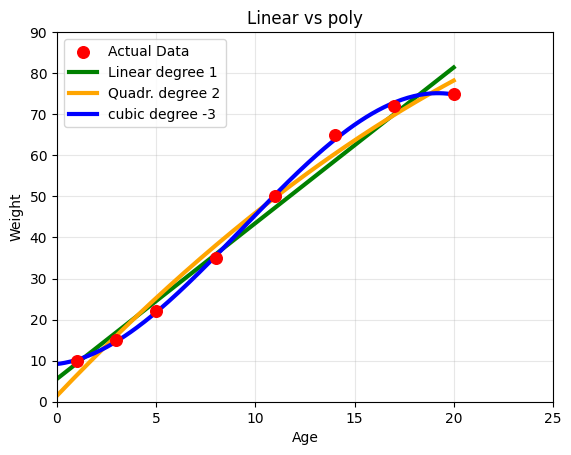

In [ ]:
plt.scatter(X,y,color='red',s=70,label="Actual Data",zorder=5)

plot_Polynomial(1,'green','Linear degree 1')
plot_Polynomial(2,'orange','Quadr. degree 2')

model_cubic , poly_cubic = plot_Polynomial(3,'blue', 'cubic degree -3 ')
plt.title("Linear vs poly")
plt.xlabel("Age")
plt.ylabel("Weight")
plt.legend()
plt.grid(True,alpha=0.3)
plt.ylim(0,90)
plt.xlim(0,25)
plt.show()
# predicted 
age_25 = poly_cubic.transform([[25]])
weight_25 = model_cubic.predict(age_25)
print(f"predicted = weight and age =  {weight_25[0]:.1f} kg")

predicted = weight and age =  54.8 kg
